# Data Roles Salary Revival

Reviving an older levels.fyi salary analysis project, this time focused on **data-analyst-adjacent roles** over time.

Two data sources are blended **but kept separate** because their methodologies differ:

| Era | Source | Methodology | Coverage |
|---|---|---|---|
| **2017-06 → 2021-08** | Kaggle *Data Science and STEM Salaries* (levels.fyi dump, via GitHub mirror) | Self-reported by tech workers. **Total comp** = base + stock + bonus. US-skewed. | 62K raw rows |
| **2020 → 2025** | ai-jobs.net `salaries.csv` (via GitHub mirror) | Aggregated from job listings. **Base salary only** (no equity). Global. | 151K raw rows |

> ⚠️ **Do not splice the two eras into one trend line.** Salaries reported in Section 1 are larger because they include stock; Section 2 is a global base-salary dataset. They tell different stories.

## Role taxonomy

The two sources expose roles very differently:

**levels.fyi era** — only a handful of canonical titles, so analyst-family roles are reconstructed from `(title, tag)`:
- **Data Scientist**: `title == "Data Scientist"`
- **Business Analyst**: `title == "Business Analyst"` *(closest stand-in for Data Analyst)*
- **Data Engineer**: `title == "Software Engineer"` + `tag in {Data, Analytics}`
- **ML Engineer**: `title == "Software Engineer"` + `tag in {ML / AI, Machine Learning, Data Science}`

**ai-jobs.net era** — titles are first-class, including *Data Analyst* and *Analytics Engineer* as canonical roles. Regex-matched on the canonical title (picks up Lead/Senior/Staff variants).

Per-role outliers below the 5th and above the 95th percentile are trimmed in both pipelines.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import levels_fyi
import aijobs_net

sns.set_theme(style='whitegrid', context='notebook')

# Shared palette so the same role gets the same colour across sections.
ALL_ROLES = ['Data Analyst', 'Business Analyst', 'Data Scientist',
             'Data Engineer', 'ML Engineer', 'Analytics Engineer']
PALETTE = dict(zip(ALL_ROLES, sns.color_palette('Set2', n_colors=len(ALL_ROLES))))

lf = levels_fyi.build()
lf['timestamp'] = pd.to_datetime(lf['timestamp'])
lf['quarter_dt'] = lf['timestamp'].dt.to_period('Q').dt.to_timestamp()

aj = aijobs_net.build()

print(f'levels.fyi:  {len(lf):,} rows, {lf["timestamp"].min().date()} → {lf["timestamp"].max().date()}')
print(f'ai-jobs.net: {len(aj):,} rows, {aj["year"].min()} → {aj["year"].max()}')

levels.fyi:  5,422 rows, 2018-06-05 → 2021-08-17
ai-jobs.net: 54,168 rows, 2020 → 2025


---
# Section 1 — Pre-2022 era (levels.fyi total comp)

Self-reported total compensation from tech workers, 2017-06 through 2021-08.

In [2]:
LF_ROLES = ['Business Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer']
lf['role'].value_counts().reindex(LF_ROLES)

role
Business Analyst     671
Data Scientist      2013
Data Engineer        706
ML Engineer         2032
Name: count, dtype: int64

### 1.1 Submissions per quarter

Sanity check on sample size before reading anything into trends.

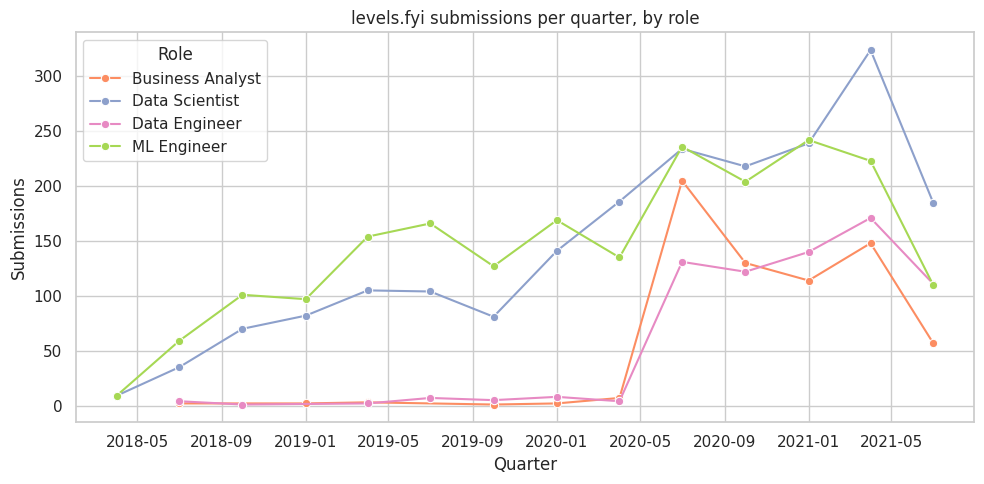

In [3]:
counts = lf.groupby(['quarter_dt', 'role']).size().reset_index(name='n')
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(counts, x='quarter_dt', y='n', hue='role', hue_order=LF_ROLES,
             palette=PALETTE, marker='o', ax=ax)
ax.set_title('levels.fyi submissions per quarter, by role')
ax.set_xlabel('Quarter'); ax.set_ylabel('Submissions')
ax.legend(title='Role', loc='upper left'); plt.tight_layout()

### 1.2 Median total comp by quarter

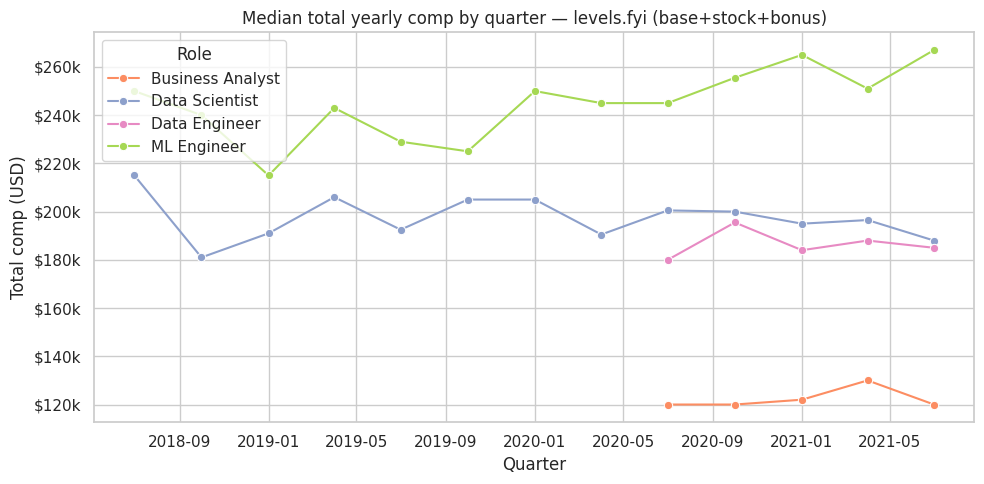

In [4]:
trend = lf.groupby(['quarter_dt', 'role'])['totalyearlycompensation'].median().reset_index()
n = lf.groupby(['quarter_dt', 'role']).size().reset_index(name='n')
trend = trend.merge(n).query('n >= 10')

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(trend, x='quarter_dt', y='totalyearlycompensation', hue='role',
             hue_order=LF_ROLES, palette=PALETTE, marker='o', ax=ax)
ax.set_title('Median total yearly comp by quarter — levels.fyi (base+stock+bonus)')
ax.set_xlabel('Quarter'); ax.set_ylabel('Total comp (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role', loc='upper left'); plt.tight_layout()

### 1.3 Compensation mix: base vs stock vs bonus

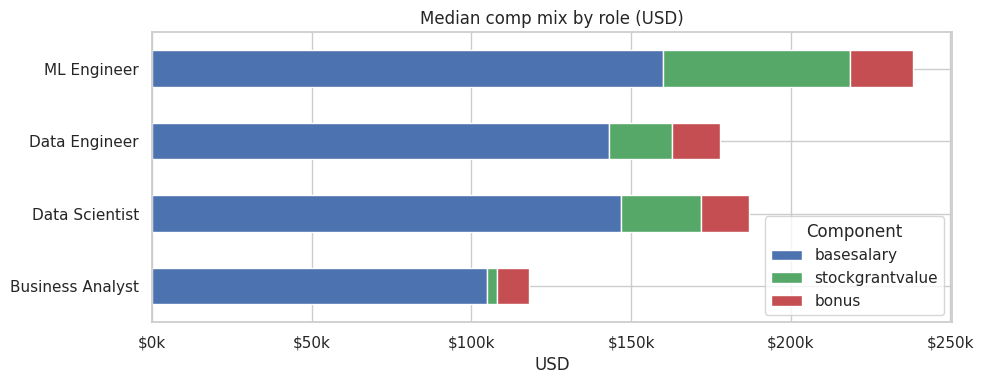

In [5]:
mix = lf.groupby('role')[['basesalary', 'stockgrantvalue', 'bonus']].median().reindex(LF_ROLES)
ax = mix.plot(kind='barh', stacked=True, figsize=(10, 4),
              color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Median comp mix by role (USD)')
ax.set_xlabel('USD'); ax.set_ylabel('')
ax.xaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Component', loc='lower right'); plt.tight_layout()

### 1.4 Experience vs total comp

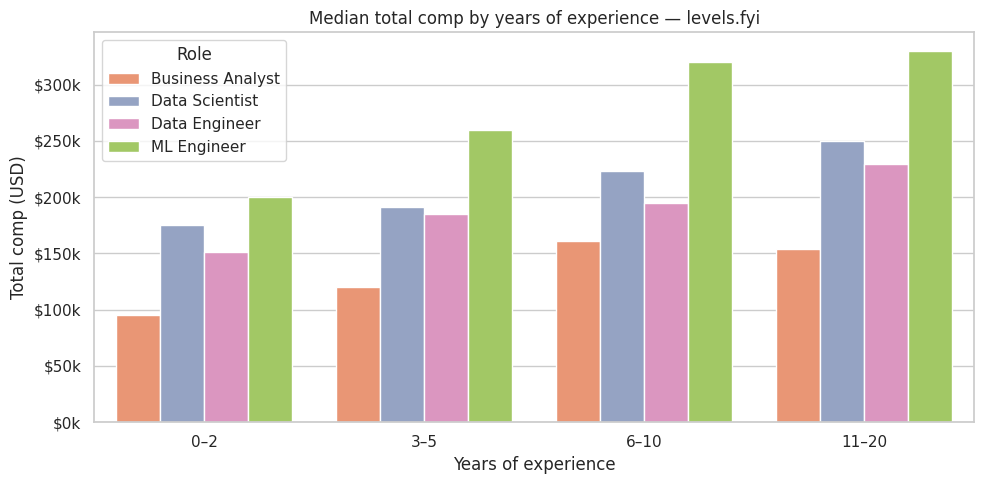

In [6]:
yoe = lf[lf['yearsofexperience'].between(0, 20)].copy()
yoe['yoe_bucket'] = pd.cut(yoe['yearsofexperience'],
                           bins=[-0.1, 2, 5, 10, 20],
                           labels=['0–2', '3–5', '6–10', '11–20'])
agg = yoe.groupby(['yoe_bucket', 'role'], observed=True)['totalyearlycompensation'].median().reset_index()
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(agg, x='yoe_bucket', y='totalyearlycompensation', hue='role',
            hue_order=LF_ROLES, palette=PALETTE, ax=ax)
ax.set_title('Median total comp by years of experience — levels.fyi')
ax.set_xlabel('Years of experience'); ax.set_ylabel('Total comp (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role'); plt.tight_layout()

---
# Section 2 — Modern era (ai-jobs.net base salary)

Posted base salaries from job listings, 2020 through 2025. Captures *Data Analyst* and *Analytics Engineer* as first-class roles (which levels.fyi didn't).

Sample is heavily back-loaded — 2020-2021 each have <300 rows, so quarterly views aren't reliable until 2022. Trend charts are gated to year/role cells with n≥30.

In [7]:
AJ_ROLES = ['Data Analyst', 'Data Scientist', 'Data Engineer', 'ML Engineer', 'Analytics Engineer']
aj['role'].value_counts().reindex(AJ_ROLES)

role
Data Analyst          12496
Data Scientist        16926
Data Engineer         14788
ML Engineer            8029
Analytics Engineer     1929
Name: count, dtype: int64

### 2.1 Submissions per year

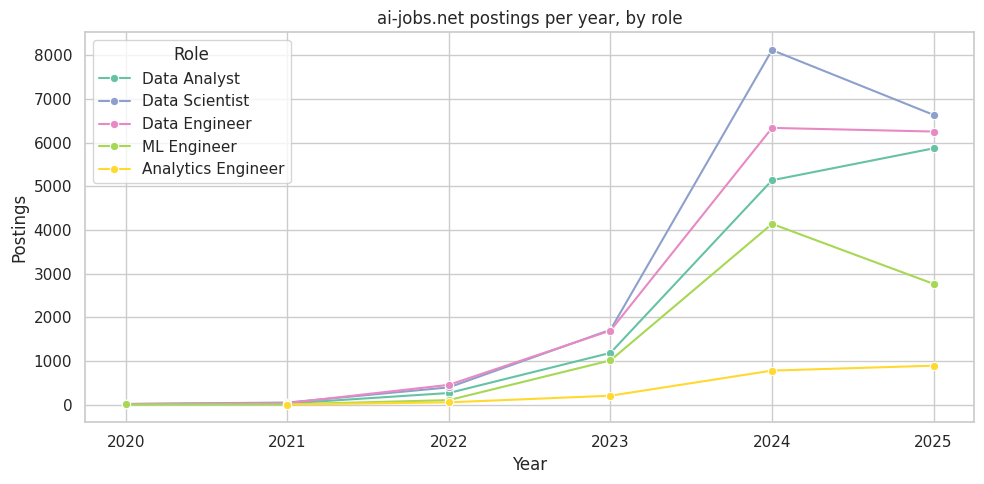

In [8]:
counts = aj.groupby(['year', 'role']).size().reset_index(name='n')
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(counts, x='year', y='n', hue='role', hue_order=AJ_ROLES,
             palette=PALETTE, marker='o', ax=ax)
ax.set_title('ai-jobs.net postings per year, by role')
ax.set_xlabel('Year'); ax.set_ylabel('Postings')
ax.legend(title='Role', loc='upper left'); plt.tight_layout()

### 2.2 Median base salary by year

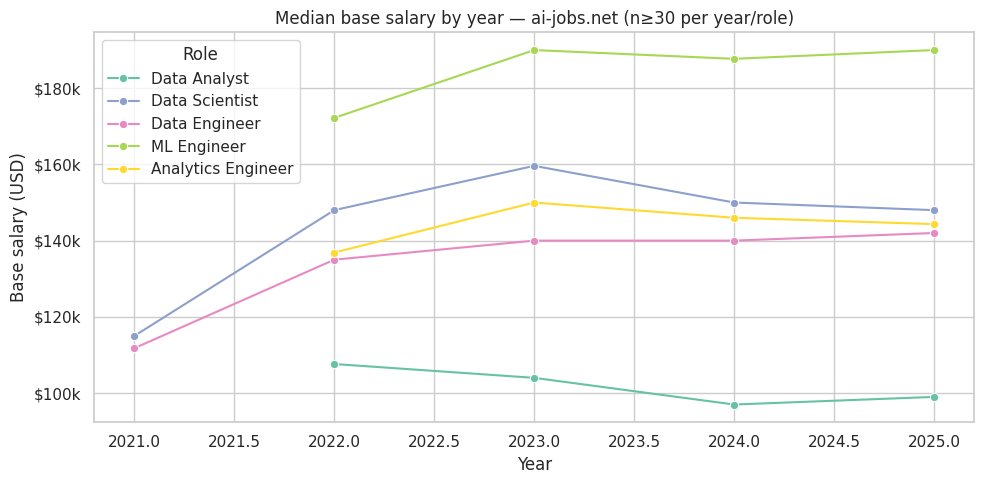

In [9]:
n = aj.groupby(['year', 'role']).size().reset_index(name='n')
trend = aj.groupby(['year', 'role'])['salary_in_usd'].median().reset_index()
trend = trend.merge(n).query('n >= 30')

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(trend, x='year', y='salary_in_usd', hue='role',
             hue_order=AJ_ROLES, palette=PALETTE, marker='o', ax=ax)
ax.set_title('Median base salary by year — ai-jobs.net (n≥30 per year/role)')
ax.set_xlabel('Year'); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role', loc='upper left'); plt.tight_layout()

### 2.3 Distribution by role (2024-2025 only)

Restricted to the recent two years where each role has thousands of observations.

/tmp/ipykernel_2838/309244360.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(recent, x='role', y='salary_in_usd', order=AJ_ROLES,


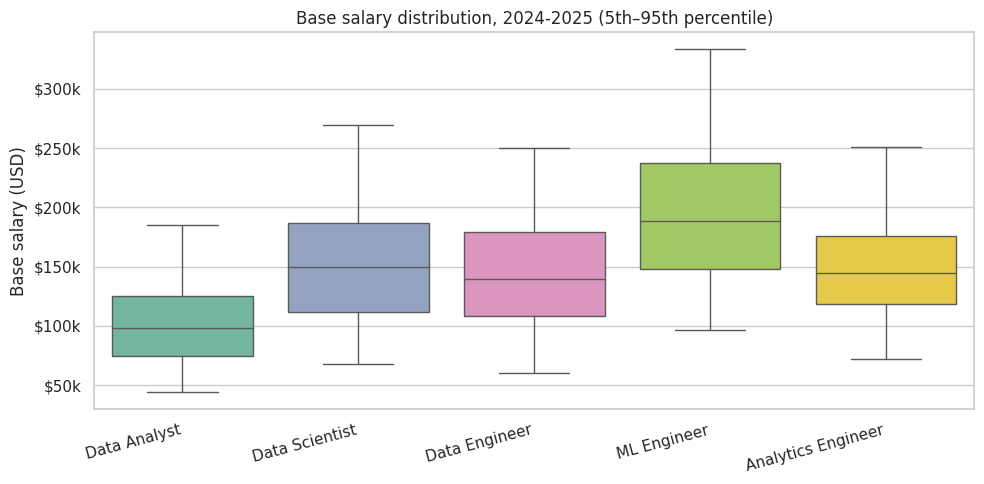

In [10]:
recent = aj[aj['year'].isin([2024, 2025])]
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(recent, x='role', y='salary_in_usd', order=AJ_ROLES,
            palette=PALETTE, ax=ax)
ax.set_title('Base salary distribution, 2024-2025 (5th–95th percentile)')
ax.set_xlabel(''); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
plt.setp(ax.get_xticklabels(), rotation=15, ha='right'); plt.tight_layout()

### 2.4 Salary by experience level (2024-2025)

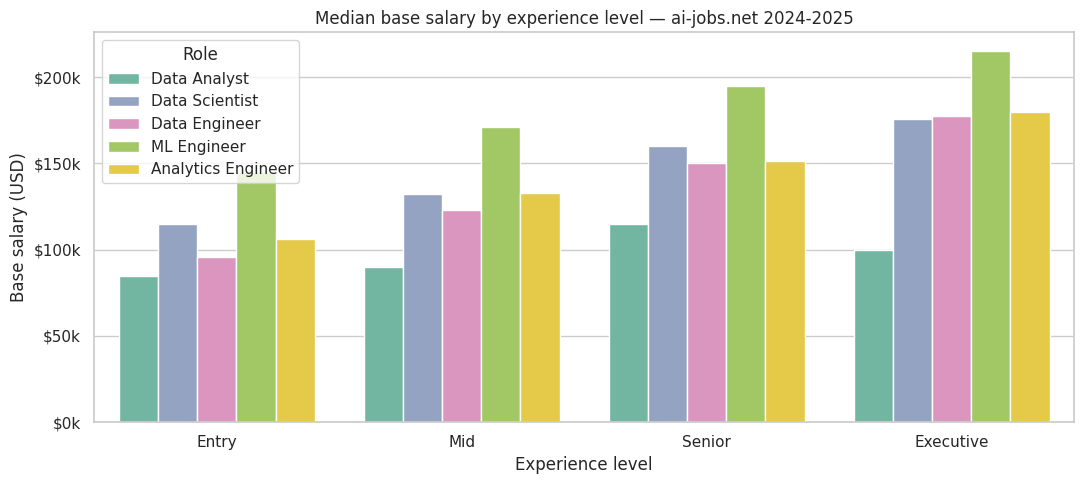

In [11]:
EXP_ORDER = ['Entry', 'Mid', 'Senior', 'Executive']
agg = (recent.groupby(['experience', 'role'], observed=True)['salary_in_usd']
             .median().reset_index())
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(agg, x='experience', y='salary_in_usd', hue='role',
            order=EXP_ORDER, hue_order=AJ_ROLES, palette=PALETTE, ax=ax)
ax.set_title('Median base salary by experience level — ai-jobs.net 2024-2025')
ax.set_xlabel('Experience level'); ax.set_ylabel('Base salary (USD)')
ax.yaxis.set_major_formatter(lambda v, _: f'${v/1000:.0f}k')
ax.legend(title='Role'); plt.tight_layout()

### 2.5 Remote-work share over time

`remote_ratio == 100` means fully remote. Calculated as the share of postings per role that are fully remote each year.

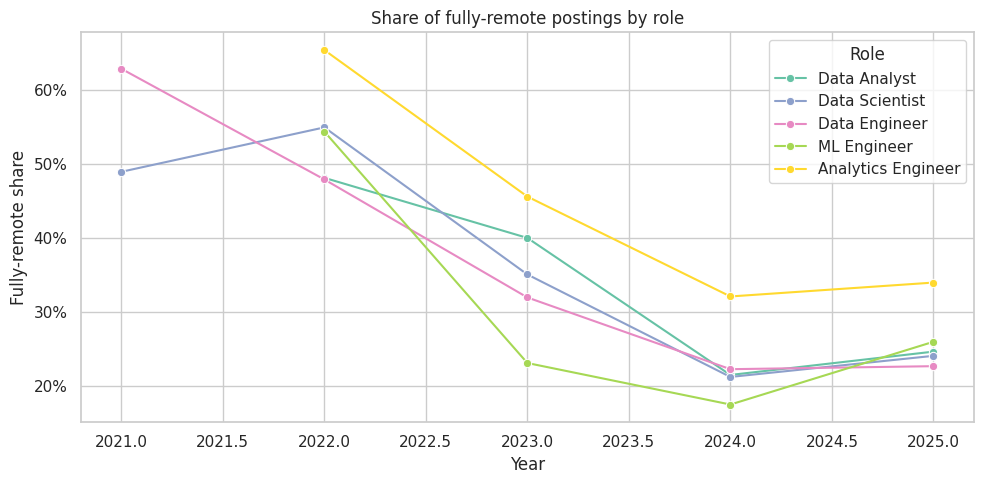

In [12]:
rem = (aj.assign(fully_remote=(aj['remote_ratio'] == 100).astype(int))
         .groupby(['year', 'role'])
         .agg(fully_remote_share=('fully_remote', 'mean'), n=('fully_remote', 'size'))
         .reset_index().query('n >= 30'))
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(rem, x='year', y='fully_remote_share', hue='role',
             hue_order=AJ_ROLES, palette=PALETTE, marker='o', ax=ax)
ax.set_title('Share of fully-remote postings by role')
ax.set_xlabel('Year'); ax.set_ylabel('Fully-remote share')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.legend(title='Role', loc='upper right'); plt.tight_layout()

### 2.6 Summary table (2024-2025)

In [13]:
summary = recent.groupby('role').agg(
    n=('salary_in_usd', 'size'),
    median_base=('salary_in_usd', 'median'),
    p25_base=('salary_in_usd', lambda s: s.quantile(0.25)),
    p75_base=('salary_in_usd', lambda s: s.quantile(0.75)),
    fully_remote_pct=('remote_ratio', lambda s: (s == 100).mean() * 100),
).reindex(AJ_ROLES).round(0).astype(int)
summary

,n,median_base,p25_base,p75_base,fully_remote_pct
role,,,,,
Data Analyst,11007,98000,75000,125600,23
Data Scientist,14755,150000,111987,187000,23
Data Engineer,12591,140000,108000,179200,22
ML Engineer,6904,188725,148000,237500,21
Analytics Engineer,1671,145000,118500,176000,33


---
## Cross-era notes

- The two sections **cannot be stacked into one trend line**. Section 1 reports total comp (base + stock + bonus, US, self-reported); Section 2 reports posted base salary (global, listings). The same role will look ~30-50% higher in Section 1 purely because of equity.
- *Data Analyst* and *Analytics Engineer* simply didn't exist as titles in the levels.fyi taxonomy of the 2017-2021 era. Business Analyst is the closest pre-2022 stand-in for Data Analyst.
- ai-jobs.net's `experience_level` is a self-reported coarse band (Entry/Mid/Senior/Executive). It's not directly comparable to levels.fyi's `yearsofexperience` integer.

## Open follow-ups

- If a continuous 2017→2025 view is wanted, do it with a **separate normalized base-only series** — strip stock/bonus out of the levels.fyi numbers and only chart base. Won't be perfect (the populations differ) but will at least apples-to-apples on the dependent variable.
- The levels.fyi `level` column is messy and company-specific. Normalizing into a coarse ladder (junior/mid/senior/staff+) would make 1.4 more legible.
- Both pipelines cache the raw CSVs under `data/` and are gitignored; re-running `python aijobs_net.py` or `python levels_fyi.py` regenerates the cleaned versions.